# Evaluate and inspect one reconstructed shoe

This notebook uses the production `mesh_metrics` implementation. It aligns the reconstructed mesh to the Blender ground truth with a rigid similarity transform, computes the same metrics as the command-line evaluator, and visualizes where the remaining errors occur. Change only the paths and options in the setup cell, then run all cells.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('/storage/Abhinay/Shell_Gaussian')
PYTHON = Path('/storage/Abhinay/home_ab5298/anaconda3/envs/shellgaussianenv/bin/python')
# Change only PRESET to switch between the available reconstructed meshes.
PRESET = 'gshell_air_jordan_1'
PRESETS = {
    'gshell_air_jordan_1': {
        'method': 'gshell',
        'shoe': 'air_jordan_1',
        'prediction': PROJECT_ROOT / 'baselines/GShell/output/golden_set_evaluation_blender_polycam_smoke/air_jordan_1_depth_polycam_blender/pass1/mesh.obj',
    },
    'gshell_birkenstock_arizona_sandal': {
        'method': 'gshell',
        'shoe': 'birkenstock_arizona_sandal',
        'prediction': PROJECT_ROOT / 'baselines/GShell/output/golden_set_evaluation_blender_polycam_smoke/birkenstock_arizona_sandal_depth_polycam_blender/pass1/mesh.obj',
    },
    'neuraludf_air_jordan_1': {
        'method': 'neuraludf',
        'shoe': 'air_jordan_1',
        'prediction': PROJECT_ROOT / 'baselines/NeuralUDF/output/open_surface_full/air_jordan_1/udf_open/udf_meshes/udf_res512_step300000.ply',
    },
}
selection = PRESETS[PRESET]
METHOD = selection['method']
SHOE = selection['shoe']
PREDICTION = selection['prediction']
SCENE = Path('/storage/Abhinay/home_ab5298/dataset/datasets/processed/golden_set_evaluation_blender') / SHOE
OUTPUT = PROJECT_ROOT / 'mesh_metrics/output/notebook_runs' / METHOD / SHOE

RUN_EVALUATION = True
RUN_FULL_HELDOUT_METRICS = False  # True renders and scores all 30 test cameras.
TRAINING_VIEW_SET = 'train'       # Use 'all' or 'unknown' when appropriate.
HELDOUT_VIEW_INDEX = 0            # 0..29; one view is visualized below.

assert PREDICTION.is_file(), PREDICTION
assert (SCENE / 'reference_mesh.ply').is_file(), SCENE
print('Available presets:', ', '.join(PRESETS))
print(f'Selected:   {PRESET}')
print(f'Prediction: {PREDICTION}')
print(f'Scene:      {SCENE}')
print(f'Output:     {OUTPUT}')

Available presets: gshell_air_jordan_1, gshell_birkenstock_arizona_sandal, neuraludf_air_jordan_1
Selected:   gshell_air_jordan_1
Prediction: /storage/Abhinay/Shell_Gaussian/baselines/GShell/output/golden_set_evaluation_blender_polycam_smoke/air_jordan_1_depth_polycam_blender/pass1/mesh.obj
Scene:      /storage/Abhinay/home_ab5298/dataset/datasets/processed/golden_set_evaluation_blender/air_jordan_1
Output:     /storage/Abhinay/Shell_Gaussian/mesh_metrics/output/notebook_runs/gshell/air_jordan_1


## Run the production evaluator

This calls `python -m mesh_metrics.evaluate_mesh`; the notebook does not maintain another alignment or metric implementation. Set `RUN_EVALUATION=False` to inspect an existing result without recomputing it.

In [2]:
if RUN_EVALUATION:
    command = [
        str(PYTHON), '-m', 'mesh_metrics.evaluate_mesh',
        '--prediction', str(PREDICTION),
        '--scene', str(SCENE),
        '--output', str(OUTPUT),
        '--training-view-set', TRAINING_VIEW_SET,
        '--save-aligned',
        '--alignment-iterations', '250',
        '--alignment-tolerance', '1e-6',
    ]
    if not RUN_FULL_HELDOUT_METRICS:
        command.append('--geometry-only')
    print(' '.join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
else:
    print('Using existing files in', OUTPUT)

/storage/Abhinay/home_ab5298/anaconda3/envs/shellgaussianenv/bin/python -m mesh_metrics.evaluate_mesh --prediction /storage/Abhinay/Shell_Gaussian/baselines/GShell/output/golden_set_evaluation_blender_polycam_smoke/air_jordan_1_depth_polycam_blender/pass1/mesh.obj --scene /storage/Abhinay/home_ab5298/dataset/datasets/processed/golden_set_evaluation_blender/air_jordan_1 --output /storage/Abhinay/Shell_Gaussian/mesh_metrics/output/notebook_runs/gshell/air_jordan_1 --training-view-set train --save-aligned --alignment-iterations 250 --alignment-tolerance 1e-6 --geometry-only
Evaluation written to /storage/Abhinay/Shell_Gaussian/mesh_metrics/output/notebook_runs/gshell/air_jordan_1
{
  "accuracy_percent": 0.28282080324662184,
  "completeness_percent": 0.8799557033528376,
  "chamfer_l1_percent": 0.5813882532997298,
  "f_score_1_percent": 0.8234747857219195,
  "normal_consistency": 0.9163185570870269,
  "p95_distance_percent": 3.3067720306409663
}


In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mesh_metrics.alignment import apply_transform
from mesh_metrics.mesh_io import load_mesh, sample_surface, transform_mesh
from mesh_metrics.surface_queries import TriangleSurface

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

alignment_report = read_json(OUTPUT / 'alignment.json')
geometry_report = read_json(OUTPUT / 'geometry_metrics.json')
view_report = read_json(OUTPUT / 'view_metrics.json') if (OUTPUT / 'view_metrics.json').is_file() else None
transform = np.asarray(alignment_report['alignment']['transform'], dtype=np.float64)
prediction_mesh = load_mesh(PREDICTION)
ground_truth_mesh = load_mesh(SCENE / 'reference_mesh.ply')
aligned_mesh = transform_mesh(prediction_mesh, transform)
diagonal = float(geometry_report['ground_truth_bbox_diagonal'])
print('Loaded evaluation reports and meshes.')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded evaluation reports and meshes.


## Alignment result

The optimizer may rotate, translate, and uniformly scale the reconstruction. It cannot reflect, shear, or deform it.

In [4]:
alignment = alignment_report['alignment']
alignment_table = pd.DataFrame({
    'Value': {
        'Initialization': alignment['initialization'],
        'Uniform scale': alignment['scale'],
        'Converged': alignment['converged'],
        'Iterations': alignment['iterations'],
        'Before error': alignment['before_error'],
        'After error': alignment['after_error'],
        'Rotation determinant': alignment['rotation_determinant'],
    }
})
display(alignment_table)

,Value
Initialization,existing_pose
Uniform scale,0.971529
Converged,True
Iterations,169
Before error,0.00537
After error,0.004527
Rotation determinant,1.0


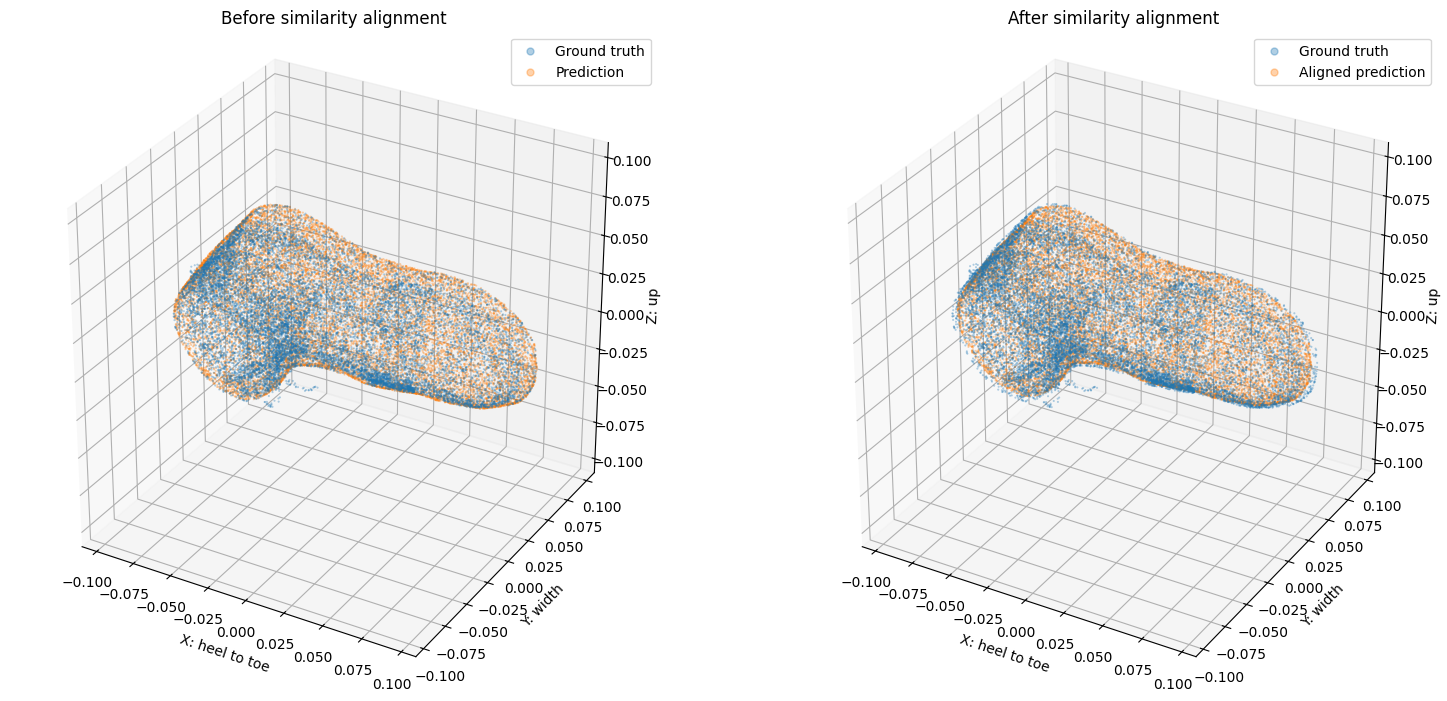

In [5]:
def equal_3d_axes(axis, point_sets):
    points = np.concatenate(point_sets, axis=0)
    center = 0.5 * (points.min(axis=0) + points.max(axis=0))
    radius = 0.52 * np.max(np.ptp(points, axis=0))
    axis.set_xlim(center[0] - radius, center[0] + radius)
    axis.set_ylim(center[1] - radius, center[1] + radius)
    axis.set_zlim(center[2] - radius, center[2] + radius)
    axis.set_box_aspect((1, 1, 1))
    axis.set_xlabel('X: heel to toe')
    axis.set_ylabel('Y: width')
    axis.set_zlabel('Z: up')

prediction_points, _ = sample_surface(prediction_mesh, 15000, seed=21)
ground_truth_points, _ = sample_surface(ground_truth_mesh, 15000, seed=22)
aligned_points = apply_transform(prediction_points, transform)

figure = plt.figure(figsize=(16, 7))
before_axis = figure.add_subplot(121, projection='3d')
before_axis.scatter(*ground_truth_points.T, s=0.25, alpha=0.35, label='Ground truth')
before_axis.scatter(*prediction_points.T, s=0.25, alpha=0.35, label='Prediction')
before_axis.set_title('Before similarity alignment')
equal_3d_axes(before_axis, [ground_truth_points, prediction_points])
before_axis.legend(markerscale=10)

after_axis = figure.add_subplot(122, projection='3d')
after_axis.scatter(*ground_truth_points.T, s=0.25, alpha=0.35, label='Ground truth')
after_axis.scatter(*aligned_points.T, s=0.25, alpha=0.35, label='Aligned prediction')
after_axis.set_title('After similarity alignment')
equal_3d_axes(after_axis, [ground_truth_points, aligned_points])
after_axis.legend(markerscale=10)
plt.tight_layout()
plt.show()

## Metric table and simple interpretation

These labels are practical diagnostic bands, not universal scientific thresholds. Distances are percentages of the ground-truth bounding-box diagonal.

In [6]:
def lower_is_better(value, strong, moderate):
    return 'Strong' if value < strong else ('Moderate' if value <= moderate else 'Poor')

def higher_is_better(value, strong, moderate):
    return 'Strong' if value > strong else ('Moderate' if value >= moderate else 'Poor')

headline = geometry_report['headline']
f_scores = geometry_report['f_scores']
metric_rows = [
    ('Accuracy', headline['accuracy_percent'], '% diagonal', lower_is_better(headline['accuracy_percent'], 0.5, 1.5)),
    ('Completeness', headline['completeness_percent'], '% diagonal', lower_is_better(headline['completeness_percent'], 0.5, 1.5)),
    ('Chamfer-L1', headline['chamfer_l1_percent'], '% diagonal', lower_is_better(headline['chamfer_l1_percent'], 0.5, 1.0)),
    ('F-score @ 0.5%', f_scores['0.5_percent']['f_score'], 'score', higher_is_better(f_scores['0.5_percent']['f_score'], 0.80, 0.50)),
    ('F-score @ 1%', f_scores['1_percent']['f_score'], 'score', higher_is_better(f_scores['1_percent']['f_score'], 0.90, 0.75)),
    ('F-score @ 2%', f_scores['2_percent']['f_score'], 'score', higher_is_better(f_scores['2_percent']['f_score'], 0.97, 0.85)),
    ('Normal consistency', headline['normal_consistency'], 'score', higher_is_better(headline['normal_consistency'], 0.90, 0.80)),
    ('P95 distance', headline['p95_distance_percent'], '% diagonal', lower_is_better(headline['p95_distance_percent'], 2.0, 5.0)),
]
if view_report is not None:
    view = view_report['headline']
    metric_rows.extend([
        ('Silhouette IoU', view['silhouette_iou'], 'score', higher_is_better(view['silhouette_iou'], 0.97, 0.90)),
        ('Boundary F-score @ 2px', view['boundary_f_score'], 'score', higher_is_better(view['boundary_f_score'], 0.70, 0.40)),
        ('Depth MAE', view['depth_mae_percent'], '% diagonal', lower_is_better(view['depth_mae_percent'], 1.0, 3.0)),
        ('Depth coverage', view['depth_overlap_coverage'], 'score', higher_is_better(view['depth_overlap_coverage'], 0.98, 0.90)),
        ('Underside depth MAE', view['underside_depth_mae_percent'], '% diagonal', lower_is_better(view['underside_depth_mae_percent'], 1.0, 3.0)),
        ('Top-view depth MAE', view['top_view_depth_mae_percent'], '% diagonal', lower_is_better(view['top_view_depth_mae_percent'], 1.0, 3.0)),
    ])
metric_table = pd.DataFrame(metric_rows, columns=['Metric', 'Value', 'Unit', 'Diagnostic band'])
display(metric_table.style.format({'Value': '{:.6f}'}))

,Metric,Value,Unit,Diagnostic band
0,Accuracy,0.282821,% diagonal,Strong
1,Completeness,0.879956,% diagonal,Moderate
2,Chamfer-L1,0.581388,% diagonal,Moderate
3,F-score @ 0.5%,0.605348,score,Moderate
4,F-score @ 1%,0.823475,score,Moderate
5,F-score @ 2%,0.939888,score,Moderate
6,Normal consistency,0.916319,score,Strong
7,P95 distance,3.306772,% diagonal,Moderate


## Surface error maps

Orange/red means farther from the other mesh. Prediction-to-GT distance exposes extra geometry (accuracy error); GT-to-prediction distance exposes missing geometry (completeness error). The calculation uses exact point-to-triangle queries, not nearest sampled points.

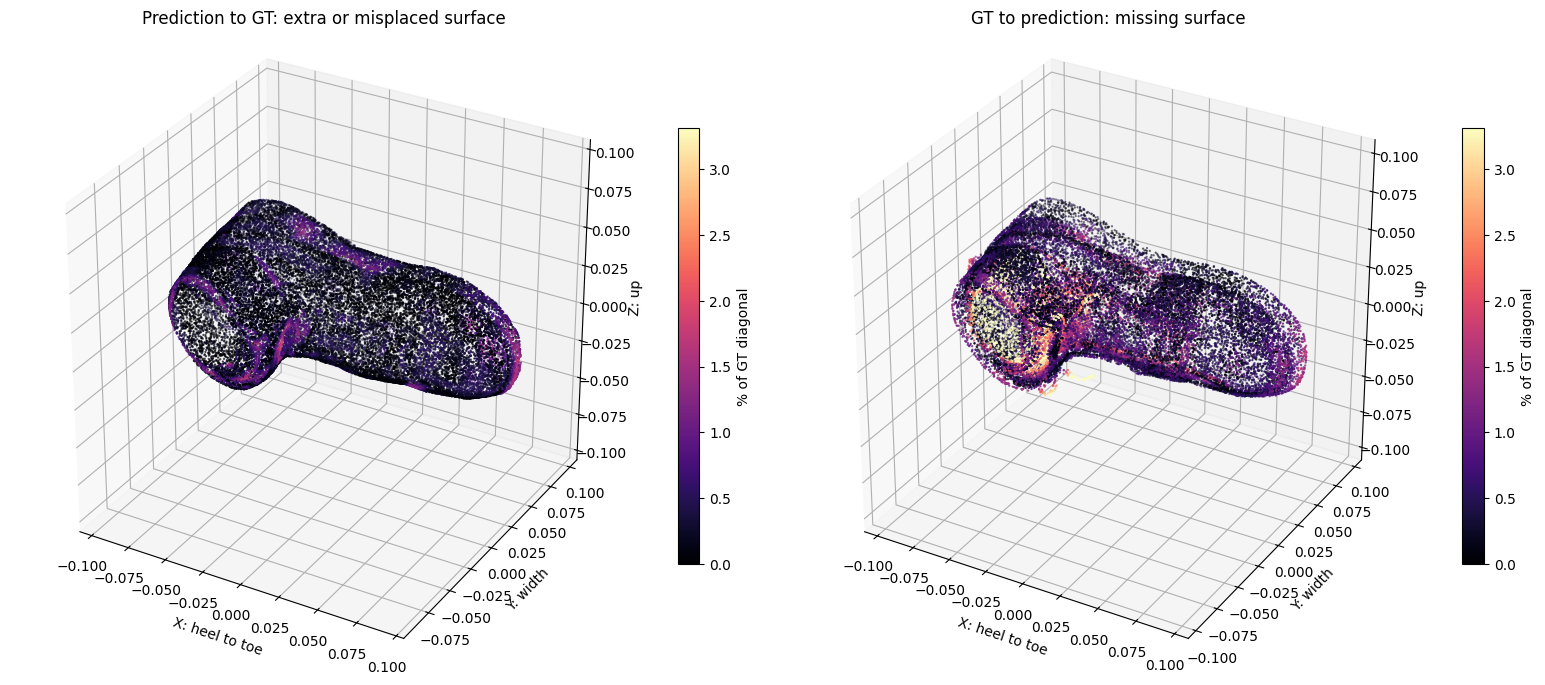

In [7]:
heatmap_count = 30000
prediction_samples, _ = sample_surface(aligned_mesh, heatmap_count, seed=31)
ground_truth_samples, _ = sample_surface(ground_truth_mesh, heatmap_count, seed=32)
prediction_error = 100.0 * TriangleSurface(ground_truth_mesh).closest_points(prediction_samples).distances / diagonal
ground_truth_error = 100.0 * TriangleSurface(aligned_mesh).closest_points(ground_truth_samples).distances / diagonal
color_max = max(np.percentile(prediction_error, 95), np.percentile(ground_truth_error, 95), 1e-6)

figure = plt.figure(figsize=(16, 7))
accuracy_axis = figure.add_subplot(121, projection='3d')
accuracy_plot = accuracy_axis.scatter(*prediction_samples.T, c=prediction_error, s=0.45, cmap='magma', vmin=0, vmax=color_max)
accuracy_axis.set_title('Prediction to GT: extra or misplaced surface')
equal_3d_axes(accuracy_axis, [prediction_samples])
figure.colorbar(accuracy_plot, ax=accuracy_axis, shrink=0.65, label='% of GT diagonal')

completeness_axis = figure.add_subplot(122, projection='3d')
completeness_plot = completeness_axis.scatter(*ground_truth_samples.T, c=ground_truth_error, s=0.45, cmap='magma', vmin=0, vmax=color_max)
completeness_axis.set_title('GT to prediction: missing surface')
equal_3d_axes(completeness_axis, [ground_truth_samples])
figure.colorbar(completeness_plot, ax=completeness_axis, shrink=0.65, label='% of GT diagonal')
plt.tight_layout()
plt.show()

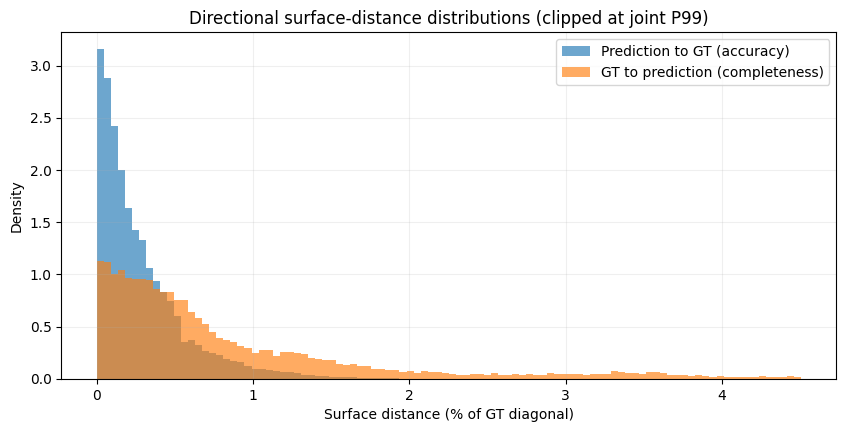

In [8]:
histogram_max = max(np.percentile(prediction_error, 99), np.percentile(ground_truth_error, 99), 1e-6)
plt.figure(figsize=(10, 4.5))
plt.hist(prediction_error, bins=100, range=(0, histogram_max), alpha=0.65, density=True, label='Prediction to GT (accuracy)')
plt.hist(ground_truth_error, bins=100, range=(0, histogram_max), alpha=0.65, density=True, label='GT to prediction (completeness)')
plt.xlabel('Surface distance (% of GT diagonal)')
plt.ylabel('Density')
plt.title('Directional surface-distance distributions (clipped at joint P99)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Mesh diagnostics

These values help explain failures but should not be used as the primary method ranking. An open shoe or a UDF reconstruction is not required to be watertight.

In [9]:
diagnostics = geometry_report['diagnostics']
display(pd.DataFrame({
    'Prediction': diagnostics['prediction'],
    'Ground truth': diagnostics['ground_truth'],
}))
print('Prediction / GT surface-area ratio:', diagnostics['prediction_to_ground_truth_surface_area_ratio'])

,Prediction,Ground truth
connected_components,16,498
boundary_edge_count,174,12778
boundary_length,0.962499,43.306525
boundary_length_over_gt_diagonal,3.816198,171.705343
nonmanifold_edge_count,0,0
vertices,1060,21089
faces,1948,29756
surface_area,0.048903,0.139244
is_watertight,False,False
postload_invalid_vertex_count,0,0


Prediction / GT surface-area ratio: 0.35120551417036056


## Inspect one held-out camera

This renders one aligned prediction from an exact Blender test camera even when the full 30-view metrics were skipped. The depth-error panel includes only pixels where both surfaces are visible.

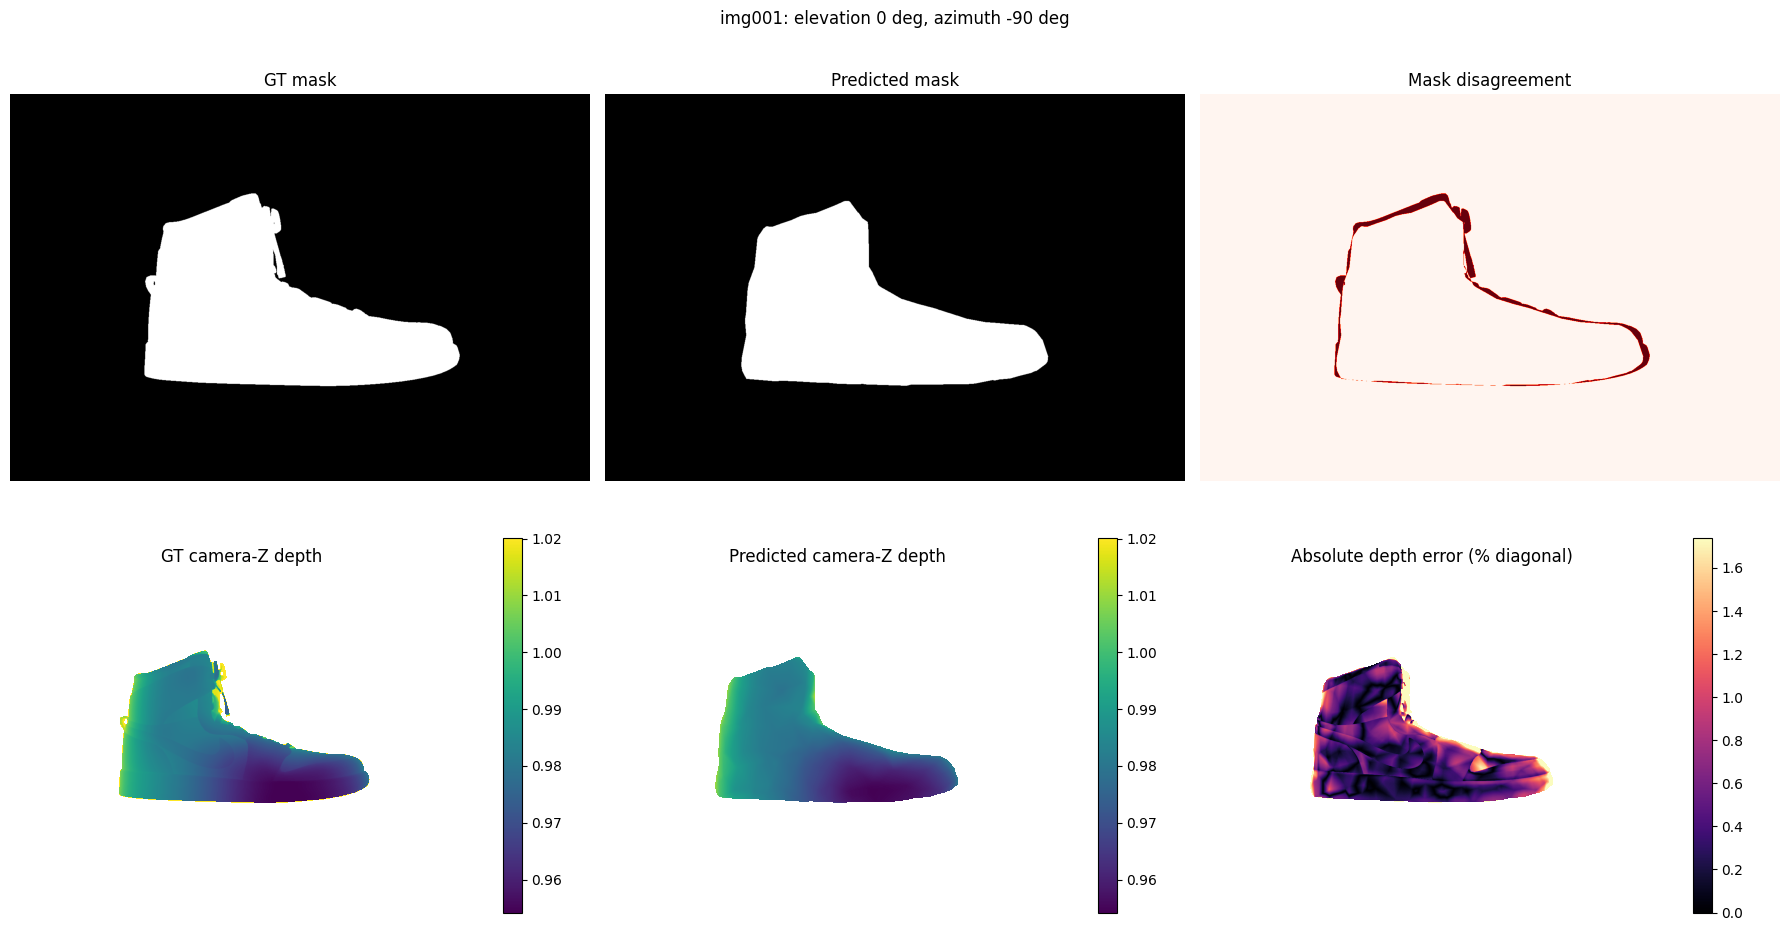

In [10]:
from mesh_metrics.camera_io import load_test_cameras
from mesh_metrics.render_metrics import HeldOutRenderer, load_ground_truth_view

cameras = load_test_cameras(SCENE)
camera = cameras[HELDOUT_VIEW_INDEX]
renderer = HeldOutRenderer(camera.width, camera.height, camera.fov_x_rad)
predicted_mask, predicted_depth = renderer.render(TriangleSurface(aligned_mesh), camera, chunk_size=250000)
ground_truth_mask, ground_truth_depth = load_ground_truth_view(camera)
disagreement = np.logical_xor(predicted_mask, ground_truth_mask)
overlap = predicted_mask & ground_truth_mask & (predicted_depth > 0) & (ground_truth_depth > 0)
depth_error = np.full(ground_truth_depth.shape, np.nan, dtype=np.float64)
depth_error[overlap] = 100.0 * np.abs(predicted_depth[overlap] - ground_truth_depth[overlap]) / diagonal
valid_depths = np.concatenate((ground_truth_depth[ground_truth_depth > 0], predicted_depth[predicted_depth > 0]))
depth_min, depth_max = np.percentile(valid_depths, [1, 99])
error_max = max(np.nanpercentile(depth_error, 95), 1e-6)

figure, axes = plt.subplots(2, 3, figsize=(18, 10))
panels = [
    (ground_truth_mask, 'GT mask', 'gray', None, None),
    (predicted_mask, 'Predicted mask', 'gray', None, None),
    (disagreement, 'Mask disagreement', 'Reds', None, None),
    (np.where(ground_truth_mask, ground_truth_depth, np.nan), 'GT camera-Z depth', 'viridis', depth_min, depth_max),
    (np.where(predicted_mask, predicted_depth, np.nan), 'Predicted camera-Z depth', 'viridis', depth_min, depth_max),
    (depth_error, 'Absolute depth error (% diagonal)', 'magma', 0, error_max),
]
for axis, (image, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    handle = axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.axis('off')
    if 'depth' in title.lower():
        figure.colorbar(handle, ax=axis, shrink=0.75)
figure.suptitle(f'{camera.frame_name}: elevation {camera.elevation_deg:g} deg, azimuth {camera.azimuth_deg:g} deg')
plt.tight_layout()
plt.show()

## Full held-out-view report

Set `RUN_FULL_HELDOUT_METRICS=True` in the setup cell and rerun to generate all view metrics. These are genuinely held out only when the method trained on the 150-frame train split.

In [11]:
if view_report is None:
    print('Full held-out metrics were skipped. Set RUN_FULL_HELDOUT_METRICS=True and rerun.')
else:
    per_view = pd.DataFrame(view_report['per_view'])
    display(pd.DataFrame({'Value': view_report['headline']}))
    display(per_view[['frame', 'elevation_deg', 'azimuth_deg', 'silhouette_iou', 'boundary_f_score', 'depth_mae_percent', 'depth_overlap_coverage']])
    figure, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].scatter(per_view['elevation_deg'], per_view['silhouette_iou'])
    axes[0].set_title('Silhouette IoU by elevation')
    axes[1].scatter(per_view['elevation_deg'], per_view['boundary_f_score'])
    axes[1].set_title('Boundary F-score by elevation')
    axes[2].scatter(per_view['elevation_deg'], per_view['depth_mae_percent'])
    axes[2].set_title('Depth MAE by elevation')
    for axis in axes:
        axis.set_xlabel('Elevation (degrees)')
        axis.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

Full held-out metrics were skipped. Set RUN_FULL_HELDOUT_METRICS=True and rerun.


## Reading the result

- High **accuracy error** means the prediction contains misplaced or extra surface.
- High **completeness error** means real parts of the shoe are missing.
- Low **normal consistency** often indicates smoothing, ripples, or locally incorrect surface orientation.
- High **P95 distance** identifies serious regional failures that averages may hide.
- Low **silhouette IoU** or boundary F-score exposes incorrect outer shape.
- High **depth error** exposes incorrect visible 3D placement even when the silhouette looks plausible.

Use the color maps to locate the failure; use the numerical report for reproducible method comparisons.